# Diagnosis

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"     # agama
os.environ["MKL_NUM_THREADS"] = "1"     # numpy, scipy
os.environ["OPENBLAS_NUM_THREADS"] = "1"    # numpy
os.environ["NUMEXPR_NUM_THREADS"] = "1"     # pandas

import agama
import torch 
import numpy as np
from scipy import integrate
# from scipy.stats import wasserstein_distance_nd
from astropy import units as u

from sbi.utils import BoxUniform

from sbi.inference import SNLE, simulate_for_sbi, prepare_for_sbi


from sbi.utils import likelihood_nn

from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd
import pickle
import matplotlib.pyplot as plt
from galaxy_generation import generate_galaxy_multiple
from prior_generation import generate_prior
from standardization import standardize
from object_handler import load_csv, load_galaxies
import corner

torch.set_num_threads(4)


## Diagnosis for Extreme velocities

In [9]:
theta, k = load_galaxies("./model_2/train_theta.csv", "ndarray")
beta = theta[:,-1]
index = np.cumsum(k)
x = load_csv("./model_2/train_x.csv", "ndarray")
lst_galaxies = np.split(x, index, axis=0)[:-1]
lst = []
for gal in lst_galaxies:
    lst.append(np.max(gal, axis=0))
np_lst = np.array(lst)
x, y, vz = np_lst[:,0], np_lst[:,1], np_lst[:,2]

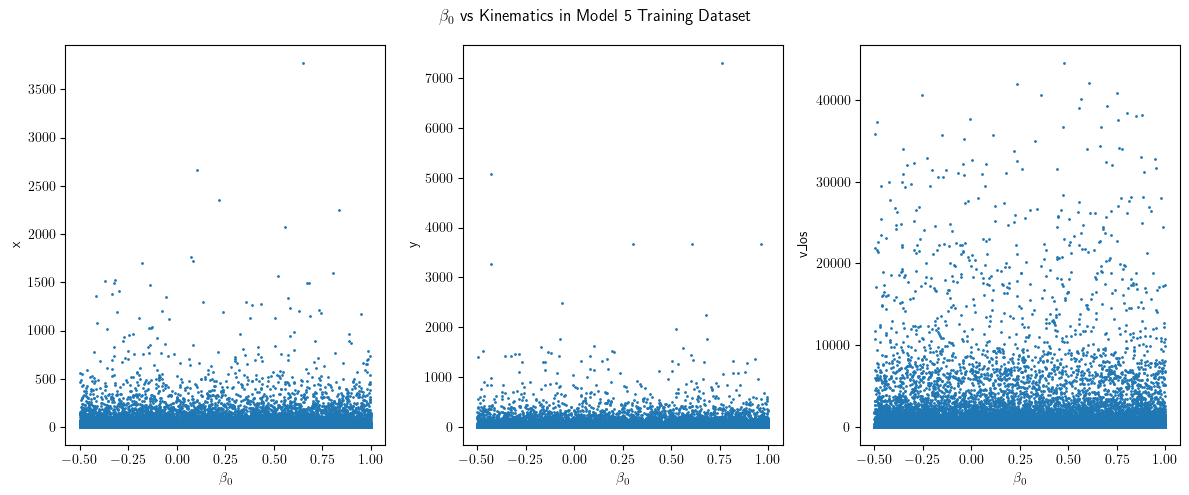

In [10]:
plt.rcParams["text.usetex"] = True
fig, axs = plt.subplots(1, 3, 
                        figsize=(12, 5),)

size = 1
axs[0].scatter(beta, x, s=size)
axs[0].set_xlabel(r"$\beta_0$")
axs[0].set_ylabel("x")

axs[1].scatter(beta, y, s=size)
axs[1].set_xlabel(r"$\beta_0$")
axs[1].set_ylabel("y")

axs[2].scatter(beta, vz, s=size)
axs[2].set_xlabel(r"$\beta_0$")
axs[2].set_ylabel("v_los")
# axs[2].plot([-0.5, 1], [1000, 1000], c="red", linestyle="--")

fig.suptitle(r"$\beta_0$ vs Kinematics in Model 5 Training Dataset")
plt.tight_layout()

## Diagnosis for distribution of uncertainties

In [9]:
uncertainties = load_csv("./model_7/train_theta.csv", "ndarray")[:, -1]

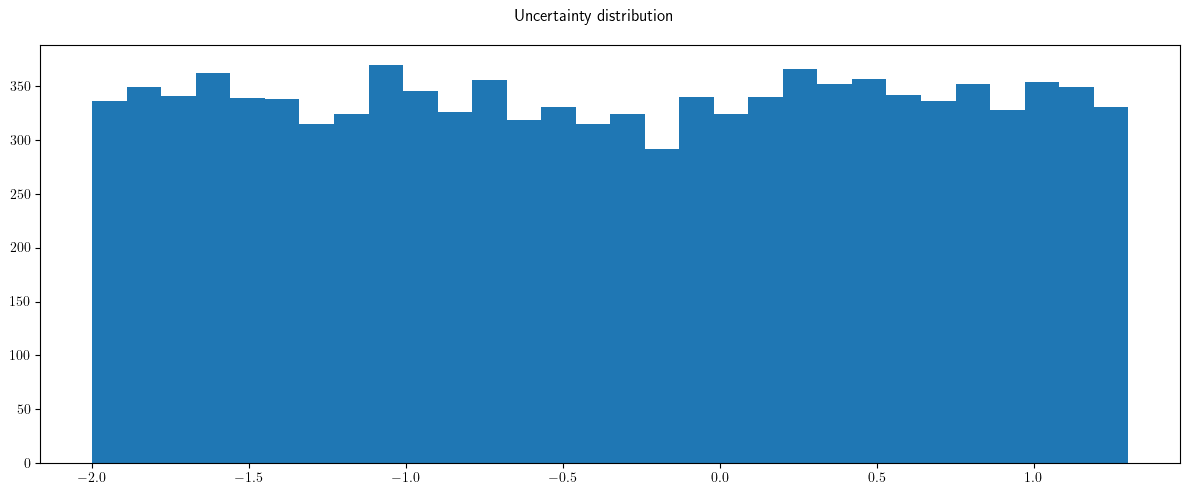

In [10]:
plt.rcParams["text.usetex"] = True
fig, axs = plt.subplots(1, 1, 
                        figsize=(12, 5),)

plt.hist(uncertainties, bins=30)

fig.suptitle(r"Uncertainty distribution")
plt.tight_layout()